<a href="https://colab.research.google.com/github/Fatma3598/elsewedy-demand-forecasting/blob/main/Dynamic_Model_Selection_Meta_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ELSEWEDY MATERIALS - HYBRID ML+DL FORECASTING MODEL

Loading dataset...
Loaded 612 records

Feature Engineering...
Features created. Dataset size after cleaning: 510

Features: 28
Target: Historical_Demand_Quantity (TON)

Training set: 408 samples
Test set: 102 samples

Creating sequences (length=6) for Deep Learning models...
   Training sequences: (402, 6, 28)
   Test sequences: (96, 6, 28)

TRAINING MACHINE LEARNING MODELS

Random Forest...
Trained

Gradient Boosting...
Trained

XGBoost...
Trained

TRAINING DEEP LEARNING MODELS

LSTM Model...
Trained (stopped at epoch 50)

TCN Model...
Trained (stopped at epoch 50)

GRU Model...
Trained (stopped at epoch 50)

MODEL EVALUATION (ALL 6 MODELS)

ML Random Forest:
   MAE:  1.58 TON
   RMSE: 2.97 TON
   R²:   0.9703
   MAPE: 4.18%

ML Gradient Boosting:
   MAE:  1.26 TON
   RMSE: 2.18 TON
   R²:   0.9840
   MAPE: 3.43%

ML XGBoost:
   MAE:  1.44 TON
   RMSE: 2.70 TON
   R²:   0.9753
   MAPE: 3.80%

DL LSTM:
   MAE:  8.44 TON
   RMSE: 12.3

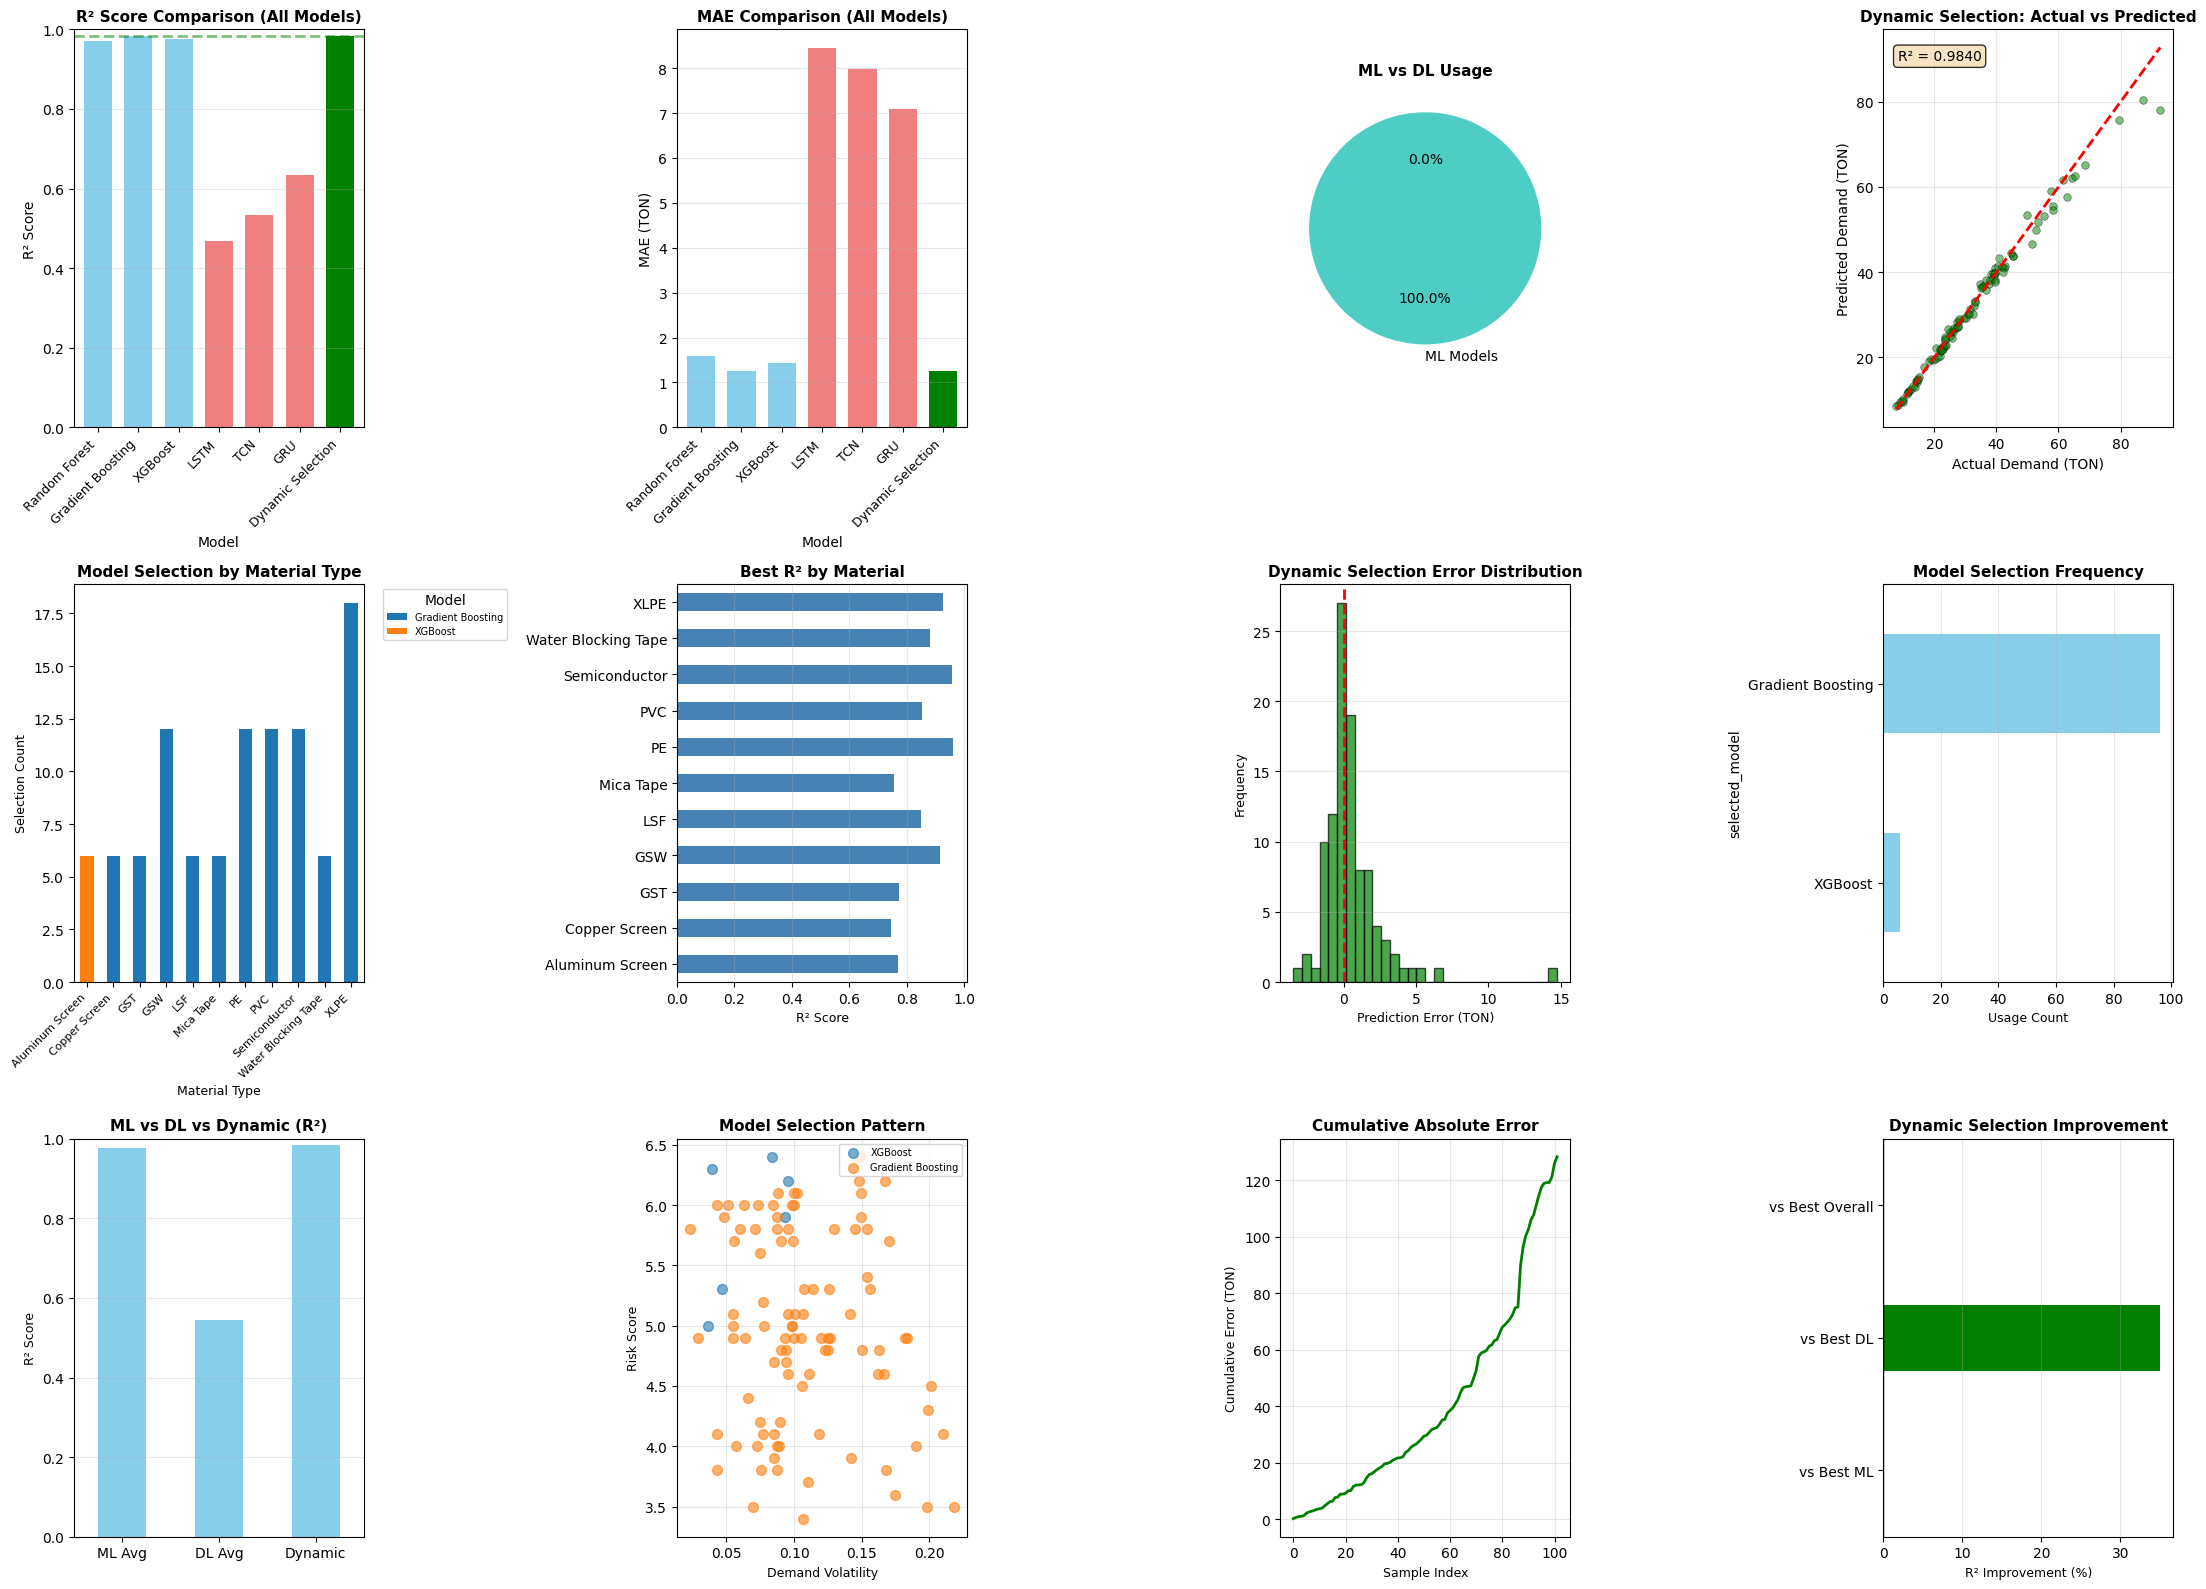

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv1D

# ============================================================================
# CONFIGURATION
# ============================================================================

FORECAST_HORIZON = 6  # months ahead
TEST_SIZE = 0.1
RANDOM_STATE = 42

# Deep Learning Configuration
SEQUENCE_LENGTH = 6  # Use 6 months of history
EPOCHS = 50
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.1

# ============================================================================
# META-LEARNING: MODEL SELECTOR CLASS
# ============================================================================

class DynamicModelSelector:
    """
    Enhanced meta-learning system that selects the best model (ML or DL)
    for each material based on historical performance and characteristics.
    """

    def __init__(self):
        self.model_performance = {}
        self.selection_history = []

    def evaluate_models_by_segment(self, models, X_test, y_test, segment_column, segment_values, is_sequence=False):
        """
        Evaluate each model's performance on different data segments
        """
        segment_performance = {}

        for segment in segment_values:
            segment_mask = segment_column == segment
            if segment_mask.sum() == 0:
                continue

            X_seg = X_test[segment_mask]
            y_seg = y_test[segment_mask]

            segment_performance[segment] = {}

            for model_name, model in models.items():
                try:
                    if is_sequence and model_name in ['LSTM', 'TCN', 'GRU']:
                        # For DL models, check if we have enough sequence data
                        if len(X_seg) < SEQUENCE_LENGTH:
                            continue
                        y_pred = model.predict(X_seg, verbose=0)
                        y_pred = y_pred.flatten()
                    else:
                        y_pred = model.predict(X_seg)

                    mae = mean_absolute_error(y_seg, y_pred)
                    rmse = np.sqrt(mean_squared_error(y_seg, y_pred))
                    r2 = r2_score(y_seg, y_pred)

                    segment_performance[segment][model_name] = {
                        'mae': mae,
                        'rmse': rmse,
                        'r2': r2,
                        'score': r2
                    }
                except Exception as e:
                    print(f"   Warning: {model_name} failed on {segment}: {str(e)[:50]}")
                    continue

        return segment_performance

    def select_best_model(self, material_type, voltage_level, risk_score, demand_volatility):
        """
        Select the best model based on material characteristics
        """
        selection_key = material_type

        if selection_key in self.model_performance:
            # Select model with best performance for this material
            best_model = max(
                self.model_performance[selection_key].items(),
                key=lambda x: x[1]['score']
            )[0]
        else:
            # Heuristics for model selection
            if demand_volatility > 0.4:
                # High volatility - prefer DL models
                best_model = 'LSTM'
            elif demand_volatility > 0.3:
                best_model = 'XGBoost'
            elif risk_score >= 7:
                best_model = 'GRU'
            elif risk_score >= 4:
                best_model = 'Gradient Boosting'
            else:
                best_model = 'Random Forest'

        self.selection_history.append({
            'material_type': material_type,
            'voltage_level': voltage_level,
            'risk_score': risk_score,
            'volatility': demand_volatility,
            'selected_model': best_model
        })

        return best_model

    def update_performance(self, segment_performance):
        """Update model performance database"""
        self.model_performance = segment_performance

    def get_selection_report(self):
        """Generate report on model selection patterns"""
        df = pd.DataFrame(self.selection_history)
        return df.groupby('selected_model').size()

# ============================================================================
# SEQUENCE GENERATION FOR DEEP LEARNING
# ============================================================================

def create_sequences(X, y, sequence_length):
    """
    Create sequences for time series DL models
    """
    X_seq = []
    y_seq = []

    for i in range(len(X) - sequence_length):
        X_seq.append(X[i:i+sequence_length])
        y_seq.append(y[i+sequence_length])

    return np.array(X_seq), np.array(y_seq)

# ============================================================================
# LOAD AND PREPARE DATA
# ============================================================================

print("ELSEWEDY MATERIALS - HYBRID ML+DL FORECASTING MODEL")
print("="*70)

print("\nLoading dataset...")
df = pd.read_csv('elsewedy_materials_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"Loaded {len(df):,} records")

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================

print("\nFeature Engineering...")

# Temporal features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfYear'] = df['Date'].dt.dayofyear

# Cyclical encoding
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Lag features
df = df.sort_values(['Item_Code', 'Date'])
for lag in [1, 2, 3, 6]:
    df[f'Demand_Lag_{lag}'] = df.groupby('Item_Code')['Historical_Demand_Quantity (TON)'].shift(lag)

# Rolling statistics
for window in [3, 6]:
    df[f'Demand_MA_{window}'] = df.groupby('Item_Code')['Historical_Demand_Quantity (TON)'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df[f'Demand_Std_{window}'] = df.groupby('Item_Code')['Historical_Demand_Quantity (TON)'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )

# Demand growth rate
df['Demand_Growth'] = df.groupby('Item_Code')['Historical_Demand_Quantity (TON)'].pct_change()

# Volatility metric
df['Demand_Volatility'] = df.groupby('Item_Code')['Historical_Demand_Quantity (TON)'].transform(
    lambda x: x.rolling(window=6, min_periods=3).std() / (x.rolling(window=6, min_periods=3).mean() + 0.01)
)

# Stock ratios
df['Stock_To_Demand_Ratio'] = df['Current_Stock_Level (TON)'] / (df['Historical_Demand_Quantity (TON)'] + 0.01)
df['Safety_Stock_Coverage'] = df['Safety_Stock_Target (TON)'] / (df['Historical_Demand_Quantity (TON)'] + 0.01)

# Categorical encoding
le_material = LabelEncoder()
le_voltage = LabelEncoder()
le_supplier = LabelEncoder()

df['Material_Type_Encoded'] = le_material.fit_transform(df['Material_Type'])
df['Voltage_Level_Encoded'] = le_voltage.fit_transform(df['Voltage_Level'])
df['Supplier_Encoded'] = le_supplier.fit_transform(df['Supplier'])

# Drop rows with NaN
df_model = df.dropna().copy()

print(f"Features created. Dataset size after cleaning: {len(df_model):,}")

# ============================================================================
# PREPARE FEATURES AND TARGET
# ============================================================================

target = 'Historical_Demand_Quantity (TON)'

feature_cols = [
    'Year', 'Month', 'Quarter', 'Month_Sin', 'Month_Cos',
    'Material_Type_Encoded', 'Voltage_Level_Encoded',
    'Demand_Lag_1', 'Demand_Lag_2', 'Demand_Lag_3', 'Demand_Lag_6',
    'Demand_MA_3', 'Demand_MA_6', 'Demand_Std_3', 'Demand_Std_6',
    'Demand_Growth', 'Demand_Volatility',
    'Current_Stock_Level (TON)', 'Safety_Stock_Target (TON)',
    'Stock_To_Demand_Ratio', 'Safety_Stock_Coverage',
    'Delivery_Lead_Time (Days)', 'Number_Of_Alternative_Suppliers',
    'Supplier_Performance_Score (1-10)', 'Risk_Score (1-10)',
    'Supplier_Encoded',
    'Price_Per_Unit (USD)', 'Market_Trends (Index)',
]

X = df_model[feature_cols].values
y = df_model[target].values

print(f"\nFeatures: {len(feature_cols)}")
print(f"Target: {target}")

# ============================================================================
# TRAIN-TEST SPLIT
# ============================================================================

split_date = df_model['Date'].quantile(0.8)
train_mask = df_model['Date'] < split_date
test_mask = df_model['Date'] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

test_segments = df_model[test_mask][['Material_Type', 'Voltage_Level', 'Risk_Score (1-10)', 'Demand_Volatility']].reset_index(drop=True)

print(f"\nTraining set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale target for DL models
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Create sequences for DL models
print(f"\nCreating sequences (length={SEQUENCE_LENGTH}) for Deep Learning models...")
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQUENCE_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, SEQUENCE_LENGTH)

print(f"   Training sequences: {X_train_seq.shape}")
print(f"   Test sequences: {X_test_seq.shape}")

n_features = X_train_scaled.shape[1]

# ============================================================================
# TRAIN MACHINE LEARNING MODELS
# ============================================================================

print("\n" + "="*70)
print("TRAINING MACHINE LEARNING MODELS")
print("="*70)

ml_models = {}
ml_predictions = {}

# 1. Random Forest
print("\nRandom Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
ml_models['Random Forest'] = rf_model
ml_predictions['Random Forest'] = rf_model.predict(X_test_scaled)
print("Trained")

# 2. Gradient Boosting
print("\nGradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    random_state=RANDOM_STATE
)
gb_model.fit(X_train_scaled, y_train)
ml_models['Gradient Boosting'] = gb_model
ml_predictions['Gradient Boosting'] = gb_model.predict(X_test_scaled)
print("Trained")

# 3. XGBoost
print("\nXGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)
ml_models['XGBoost'] = xgb_model
ml_predictions['XGBoost'] = xgb_model.predict(X_test_scaled)
print("Trained")

# ============================================================================
# TRAIN DEEP LEARNING MODELS
# ============================================================================

print("\n" + "="*70)
print("TRAINING DEEP LEARNING MODELS")
print("="*70)

dl_models = {}
dl_predictions = {}

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=0
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    verbose=0
)

# 1. LSTM
print("\nLSTM Model...")
lstm_model = models.Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(SEQUENCE_LENGTH, n_features),
         kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),

    LSTM(32, return_sequences=False,
         kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),

    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mae']
)

history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

# Predict and inverse transform
y_pred_scaled = lstm_model.predict(X_test_seq, verbose=0)
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_pred_lstm = np.maximum(y_pred_lstm, 0)

# Align with original test set (pad with NaN for sequence offset)
y_pred_lstm_full = np.full(len(y_test), np.nan)
y_pred_lstm_full[SEQUENCE_LENGTH:] = y_pred_lstm
dl_predictions['LSTM'] = y_pred_lstm_full

dl_models['LSTM'] = lstm_model
print(f"Trained (stopped at epoch {len(history_lstm.history['loss'])})")

# 2. TCN
print("\nTCN Model...")
inputs = layers.Input(shape=(SEQUENCE_LENGTH, n_features))
x = inputs

x = Conv1D(filters=32, kernel_size=2, dilation_rate=1, padding='causal',
           activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = Dropout(0.3)(x)

x = Conv1D(filters=32, kernel_size=2, dilation_rate=2, padding='causal',
           activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = Dropout(0.3)(x)

x = layers.GlobalAveragePooling1D()(x)
x = Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = Dropout(0.2)(x)
outputs = Dense(1)(x)

tcn_model = models.Model(inputs=inputs, outputs=outputs)

tcn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mae']
)

history_tcn = tcn_model.fit(
    X_train_seq, y_train_seq,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

y_pred_scaled = tcn_model.predict(X_test_seq, verbose=0)
y_pred_tcn = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_pred_tcn = np.maximum(y_pred_tcn, 0)

y_pred_tcn_full = np.full(len(y_test), np.nan)
y_pred_tcn_full[SEQUENCE_LENGTH:] = y_pred_tcn
dl_predictions['TCN'] = y_pred_tcn_full

dl_models['TCN'] = tcn_model
print(f"Trained (stopped at epoch {len(history_tcn.history['loss'])})")

# 3. GRU
print("\nGRU Model...")
gru_model = models.Sequential([
    layers.GRU(64, return_sequences=True,
               input_shape=(SEQUENCE_LENGTH, n_features),
               kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),

    layers.GRU(32, return_sequences=False,
               kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),

    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mae']
)

history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

y_pred_scaled = gru_model.predict(X_test_seq, verbose=0)
y_pred_gru = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_pred_gru = np.maximum(y_pred_gru, 0)

y_pred_gru_full = np.full(len(y_test), np.nan)
y_pred_gru_full[SEQUENCE_LENGTH:] = y_pred_gru
dl_predictions['GRU'] = y_pred_gru_full

dl_models['GRU'] = gru_model
print(f"Trained (stopped at epoch {len(history_gru.history['loss'])})")

# ============================================================================
# COMBINE ALL MODELS
# ============================================================================

all_models = {**ml_models, **dl_models}
all_predictions = {**ml_predictions, **dl_predictions}

# ============================================================================
# MODEL EVALUATION
# ============================================================================

print("\n" + "="*70)
print("MODEL EVALUATION (ALL 6 MODELS)")
print("="*70)

results = []

for name, y_pred in all_predictions.items():
    # Handle NaN values for DL models
    valid_mask = ~np.isnan(y_pred)
    y_test_valid = y_test[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_pred_valid) == 0:
        continue

    mae = mean_absolute_error(y_test_valid, y_pred_valid)
    rmse = np.sqrt(mean_squared_error(y_test_valid, y_pred_valid))
    r2 = r2_score(y_test_valid, y_pred_valid)
    mape = np.mean(np.abs((y_test_valid - y_pred_valid) / (y_test_valid + 0.01))) * 100

    model_type = "ML" if name in ml_models else "DL"

    results.append({
        'Model': name,
        'Type': model_type,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape
    })

    print(f"\n{model_type} {name}:")
    print(f"   MAE:  {mae:.2f} TON")
    print(f"   RMSE: {rmse:.2f} TON")
    print(f"   R²:   {r2:.4f}")
    print(f"   MAPE: {mape:.2f}%")

results_df = pd.DataFrame(results)

# ============================================================================
# META-LEARNING: SEGMENT-BASED EVALUATION
# ============================================================================

print("\n" + "="*70)
print("META-LEARNING: DYNAMIC MODEL SELECTION")
print("="*70)

model_selector = DynamicModelSelector()

# Evaluate ML models by material type
print("\nEvaluating models by Material Type...")
material_performance = model_selector.evaluate_models_by_segment(
    all_models,
    X_test_scaled,
    y_test,
    test_segments['Material_Type'].values,
    test_segments['Material_Type'].unique(),
    is_sequence=False
)

# Display top performers
print("\n" + "="*70)
print("BEST MODEL BY MATERIAL TYPE")
print("="*70)

for material, perf in sorted(material_performance.items()):
    if len(perf) == 0:
        continue
    best = max(perf.items(), key=lambda x: x[1]['score'])
    model_type = "ML" if best[0] in ml_models else "DL"
    print(f"\n{material}:")
    print(f"BEST: {model_type} {best[0]} (R² = {best[1]['r2']:.4f}, MAE = {best[1]['mae']:.2f})")

model_selector.update_performance(material_performance)

# ============================================================================
# DYNAMIC PREDICTIONS
# ============================================================================

print("\nGenerating Dynamic Predictions...")

dynamic_predictions = []

for idx in range(len(X_test)):
    material_type = test_segments.iloc[idx]['Material_Type']
    voltage_level = test_segments.iloc[idx]['Voltage_Level']
    risk_score = test_segments.iloc[idx]['Risk_Score (1-10)']
    volatility = test_segments.iloc[idx]['Demand_Volatility']

    selected_model_name = model_selector.select_best_model(
        material_type, voltage_level, risk_score, volatility
    )

    selected_model = all_models[selected_model_name]

    # Get prediction based on model type
    if selected_model_name in ml_models:
        pred = selected_model.predict(X_test_scaled[idx:idx+1])[0]
    else:
        # For DL models, skip if not enough sequence data
        if idx < SEQUENCE_LENGTH:
            # Use best ML model for first few predictions
            pred = ml_models['Gradient Boosting'].predict(X_test_scaled[idx:idx+1])[0]
        else:
            pred = all_predictions[selected_model_name][idx]

    dynamic_predictions.append(pred)

dynamic_predictions = np.array(dynamic_predictions)

# Evaluate dynamic selection
mae_dynamic = mean_absolute_error(y_test, dynamic_predictions)
rmse_dynamic = np.sqrt(mean_squared_error(y_test, dynamic_predictions))
r2_dynamic = r2_score(y_test, dynamic_predictions)
mape_dynamic = np.mean(np.abs((y_test - dynamic_predictions) / (y_test + 0.01))) * 100

results.append({
    'Model': 'Dynamic Selection',
    'Type': 'Meta',
    'MAE': mae_dynamic,
    'RMSE': rmse_dynamic,
    'R²': r2_dynamic,
    'MAPE (%)': mape_dynamic
})

print(f"\nDynamic Selection (Meta-Learning):")
print(f"   MAE:  {mae_dynamic:.2f} TON")
print(f"   RMSE: {rmse_dynamic:.2f} TON")
print(f"   R²:   {r2_dynamic:.4f}")
print(f"   MAPE: {mape_dynamic:.2f}%")

results_df = pd.DataFrame(results)

# Model selection statistics
print("\n" + "="*70)
print("MODEL SELECTION STATISTICS")
print("="*70)
selection_counts = model_selector.get_selection_report()
print("\nModel Usage Frequency:")
for model, count in selection_counts.items():
    percentage = (count / len(dynamic_predictions)) * 100
    model_type = "ML" if model in ml_models else "DL"
    print(f"   {model_type} {model:20s}: {count:4d} times ({percentage:.1f}%)")

best_single = results_df.iloc[:-1].loc[results_df.iloc[:-1]['R²'].idxmax()]
print(f"\nBest Single Model: {best_single['Type']} {best_single['Model']} (R² = {best_single['R²']:.4f})")
improvement = r2_dynamic - results_df.iloc[:-1]['R²'].max()
print(f"Dynamic Selection Improvement: {improvement:.4f} R² points")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\nGenerating comprehensive visualizations...")

fig = plt.figure(figsize=(22, 16))

# 1. Model Comparison - R²
ax1 = plt.subplot(3, 4, 1)
colors = ['skyblue']*3 + ['lightcoral']*3 + ['green']
results_df.plot(x='Model', y='R²', kind='bar', ax=ax1, color=colors, width=0.7, legend=False)
plt.title('R² Score Comparison (All Models)', fontsize=11, fontweight='bold')
plt.ylabel('R² Score')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.axhline(y=r2_dynamic, color='green', linestyle='--', linewidth=2, alpha=0.5)

# 2. MAE Comparison
ax2 = plt.subplot(3, 4, 2)
results_df.plot(x='Model', y='MAE', kind='bar', ax=ax2, color=colors, width=0.7, legend=False)
plt.title('MAE Comparison (All Models)', fontsize=11, fontweight='bold')
plt.ylabel('MAE (TON)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# 3. Model Type Distribution
ax3 = plt.subplot(3, 4, 3)
ml_count = sum(1 for m in selection_counts.index if m in ml_models)
dl_count = len(selection_counts) - ml_count
type_counts = pd.Series({'ML Models': selection_counts[selection_counts.index.isin(ml_models)].sum(),
                         'DL Models': selection_counts[~selection_counts.index.isin(ml_models)].sum()})
type_counts.plot(kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90, colors=['#4ECDC4', '#FF6B6B'])
plt.title('ML vs DL Usage', fontsize=11, fontweight='bold')
plt.ylabel('')

# 4. Actual vs Predicted (Dynamic)
ax4 = plt.subplot(3, 4, 4)
plt.scatter(y_test, dynamic_predictions, alpha=0.5, s=30, c='green', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Dynamic Selection: Actual vs Predicted', fontsize=11, fontweight='bold')
plt.xlabel('Actual Demand (TON)')
plt.ylabel('Predicted Demand (TON)')
plt.grid(True, alpha=0.3)
plt.text(0.05, 0.95, f'R² = {r2_dynamic:.4f}', transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 5. Model Selection by Material
ax5 = plt.subplot(3, 4, 5)
selection_df = pd.DataFrame(model_selector.selection_history)
selection_by_material = selection_df.groupby(['material_type', 'selected_model']).size().unstack(fill_value=0)
selection_by_material.plot(kind='bar', stacked=True, ax=ax5)
plt.title('Model Selection by Material Type', fontsize=11, fontweight='bold')
plt.xlabel('Material Type', fontsize=9)
plt.ylabel('Selection Count', fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

# 6. Performance by Material Type
ax6 = plt.subplot(3, 4, 6)
material_r2 = {}
for material in material_performance.keys():
    if len(material_performance[material]) > 0:
        material_r2[material] = max(material_performance[material].items(),
                                   key=lambda x: x[1]['score'])[1]['r2']
pd.Series(material_r2).plot(kind='barh', ax=ax6, color='steelblue')
plt.title('Best R² by Material', fontsize=11, fontweight='bold')
plt.xlabel('R² Score', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')

# 7. Error Distribution
ax7 = plt.subplot(3, 4, 7)
errors_dynamic = y_test - dynamic_predictions
plt.hist(errors_dynamic, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.title('Dynamic Selection Error Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Prediction Error (TON)', fontsize=9)
plt.ylabel('Frequency', fontsize=9)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3, axis='y')

# 8. Model Selection Frequency
ax8 = plt.subplot(3, 4, 8)
selection_counts_sorted = selection_counts.sort_values(ascending=True)
colors_bar = ['skyblue' if m in ml_models else 'lightcoral' for m in selection_counts_sorted.index]
selection_counts_sorted.plot(kind='barh', ax=ax8, color=colors_bar)
plt.title('Model Selection Frequency', fontsize=11, fontweight='bold')
plt.xlabel('Usage Count', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')

# 9. ML vs DL Performance
ax9 = plt.subplot(3, 4, 9)
ml_results = results_df[results_df['Type'].str.contains('ML')]
dl_results = results_df[results_df['Type'].str.contains('DL')]
comparison = pd.DataFrame({
    'ML Avg': [ml_results['R²'].mean()],
    'DL Avg': [dl_results['R²'].mean()],
    'Dynamic': [r2_dynamic]
})
comparison.T.plot(kind='bar', ax=ax9, legend=False, color=['skyblue', 'lightcoral', 'green'])
plt.title('ML vs DL vs Dynamic (R²)', fontsize=11, fontweight='bold')
plt.ylabel('R² Score', fontsize=9)
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')

# 10. Volatility vs Model Selection
ax10 = plt.subplot(3, 4, 10)
for model_name in selection_df['selected_model'].unique():
    model_data = selection_df[selection_df['selected_model'] == model_name]
    marker = 'o' if model_name in ml_models else '^'
    plt.scatter(model_data['volatility'], model_data['risk_score'],
               label=model_name, alpha=0.6, s=50, marker=marker)
plt.title('Model Selection Pattern', fontsize=11, fontweight='bold')
plt.xlabel('Demand Volatility', fontsize=9)
plt.ylabel('Risk Score', fontsize=9)
plt.legend(fontsize=7, loc='best')
plt.grid(True, alpha=0.3)

# 11. Cumulative Error
ax11 = plt.subplot(3, 4, 11)
cumulative_error = np.cumsum(np.abs(errors_dynamic))
plt.plot(cumulative_error, linewidth=2, color='green')
plt.title('Cumulative Absolute Error', fontsize=11, fontweight='bold')
plt.xlabel('Sample Index', fontsize=9)
plt.ylabel('Cumulative Error (TON)', fontsize=9)
plt.grid(True, alpha=0.3)

# 12. Improvement Summary
ax12 = plt.subplot(3, 4, 12)
improvement_metrics = {
    'vs Best ML': [(r2_dynamic - ml_results['R²'].max()) * 100],
    'vs Best DL': [(r2_dynamic - dl_results['R²'].max()) * 100],
    'vs Best Overall': [(r2_dynamic - results_df.iloc[:-1]['R²'].max()) * 100]
}
improvement_df = pd.DataFrame(improvement_metrics, index=['Improvement'])
improvement_df.T.plot(kind='barh', ax=ax12, legend=False,
                      color=['green' if x >= 0 else 'red' for x in improvement_df.values[0]])
plt.title('Dynamic Selection Improvement', fontsize=11, fontweight='bold')
plt.xlabel('R² Improvement (%)', fontsize=9)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('hybrid_ml_dl_dynamic_results.png', dpi=300, bbox_inches='tight')
print("Saved: hybrid_ml_dl_dynamic_results.png")

# Save results
results_df.to_csv('model_comparison_results.csv', index=False)
print("Saved: model_comparison_results.csv")

print("\n" + "="*70)
print("HYBRID ML+DL ANALYSIS COMPLETE!")
print("="*70)

print("\nKEY INSIGHTS:")
print(f"\nBest Models by Category:")
print(f"   • Best ML Model: {ml_results.loc[ml_results['R²'].idxmax(), 'Model']} (R² = {ml_results['R²'].max():.4f})")
print(f"   • Best DL Model: {dl_results.loc[dl_results['R²'].idxmax(), 'Model']} (R² = {dl_results['R²'].max():.4f})")
print(f"   • Dynamic Selection: R² = {r2_dynamic:.4f}")

print(f"\nModel Usage:")
ml_usage = selection_counts[selection_counts.index.isin(ml_models)].sum()
dl_usage = selection_counts[~selection_counts.index.isin(ml_models)].sum()
print(f"   • ML Models: {ml_usage} selections ({ml_usage/len(dynamic_predictions)*100:.1f}%)")
print(f"   • DL Models: {dl_usage} selections ({dl_usage/len(dynamic_predictions)*100:.1f}%)")

print(f"\nPerformance Improvement:")
print(f"   • vs Best ML: {(r2_dynamic - ml_results['R²'].max()):.4f} R² points")
print(f"   • vs Best DL: {(r2_dynamic - dl_results['R²'].max()):.4f} R² points")
print(f"   • vs Best Overall: {improvement:.4f} R² points")